# 202_01 — Simulación y preprocesamiento · Escenario: multimodalidad en los scores

Paso **1 de 5** del ciclo `Python → MATLAB → Python`:
- 01: **este notebook** genera los datos, toma la base de Fourier del generador como representación (**scores crudos, sin estandarizar**) y escribe los datasets AR
- 02: `psbp_fd_iteracion.m` muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento
- 03, 04, 05: `202_03_convergencia` / `202_04_evaluacion` / `202_05_comparacion`

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de experimento.



## 1. Imports y rutas

In [2]:
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generadores y contrato de artefactos
from model_psbp_fd.pipelines import (
    ConfigEscenarioC1, generar_escenario_C1,
    guardar_escenario,
    guardar_curvas, guardar_representacion
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2
)
from model_psbp_fd.fit.preparacion_barrido import preparar_punto
# Rutas del contrato y convención del EXPERIMENT_ID: el gemelo Python de
# config_paths.m. Antes esta sección armaba el dict PATHS a mano.
from model_psbp_fd.utils import (
    get_project_root, experiment_id, normalizar_lista_M,
    rutas_por_M, guardar_en_todos, replicar_figura
)
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_series_componentes,
    plot_diagnostico_rezagos
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline


### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [3]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Variantes de la 202 (una por defecto). Se corre este notebook UNA VEZ POR VARIANTE.
VARIANTES = {
    # Chung §4.2 en escala cruda, gating libre (taupsij_z = 10) y covariables CRUZADAS
    # (todos los rezagos de todas las componentes: p = M x N_LAGS; se entrena cada M).
    "chungEscX": {"hiperparametros": "chung_escala_cruda", "N": 30, "covariables": "cruzados",
                  "taupsij_z": 10.0},
}
VARIANTE = "chungEscX"

VAR_CFG      = {"covariables": "propio", **VARIANTES[VARIANTE]}
CRUZADOS     = VAR_CFG["covariables"] == "cruzados"
BASENAME     = f"escenario_202_{VARIANTE}"
ESCENARIO_ID = 1      # escenario multimodalidad en los scores (único)
REPLICA_ID   = 1      # réplica Monte Carlo
SEED         = 41232  # semilla base; MATLAB la LEE de hyperparameters.json

# Especificar componentes a estudiar 
M_FPCA_LIST = (3, 4, 5, 6)

LIMPIAR_DIRECTORIOS = False

# FUnciones
M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
M_ENTRENO       = max(M_FPCA_LIST)   # rezago propio: único M que se entrena (cruzados: todos)
EXPERIMENT_BASE = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID)

print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"VARIANTE        : {VARIANTE}  {VAR_CFG}")
print(f"Escenario {ESCENARIO_ID} · réplica {REPLICA_ID} · seed base {SEED}")
print(f"barrido en M    : {list(M_FPCA_LIST)}   (se entrena solo M={M_ENTRENO})")
for _M in M_FPCA_LIST:
    print(f"   M={_M}  ->  {experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M)}")


PROJECT_ROOT    : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_BASE : escenario_202_chungEscX_1_r01
VARIANTE        : chungEscX  {'covariables': 'cruzados', 'hiperparametros': 'chung_escala_cruda', 'N': 30, 'taupsij_z': 10.0}
Escenario 1 · réplica 1 · seed base 41232
barrido en M    : [3, 4, 5, 6]   (se entrena solo M=6)
   M=3  ->  escenario_202_chungEscX_1_r01_m03
   M=4  ->  escenario_202_chungEscX_1_r01_m04
   M=5  ->  escenario_202_chungEscX_1_r01_m05
   M=6  ->  escenario_202_chungEscX_1_r01_m06


In [4]:
PATHS_POR_M = rutas_por_M(BASENAME, ESCENARIO_ID, REPLICA_ID, M_FPCA_LIST,
                          dominio="simulaciones", project_root=PROJECT_ROOT,
                          limpiar=LIMPIAR_DIRECTORIOS)

for M, p in PATHS_POR_M.items():
    print(f"M={M}  ({experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)})")
    for nombre, ruta in p.items():
        print(f"  {nombre:12s} -> {ruta}")

M=3  (escenario_202_chungEscX_1_r01_m03)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_202_chungEscX_1_r01_m03
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_202_chungEscX_1_r01_m03
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_202_chungEscX_1_r01_m03
  out_report   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_202_chungEscX_1_r01_m03
  out_artefact -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_202_chungEscX_1_r01_m03
M=4  (escenario_202_chungEscX_1_r01_m04)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_202_chungEscX_1_r01_m04
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\s

### 2.1 `[CONFIG]` Parámetros del generador

`sim_escenario_C1` (anexo, algoritmo C-3): $X_t(\tau)=\mu(\tau)+\sum_{j=1}^{10}\xi_{tj}\varphi_j(\tau)$ con la base de Fourier y $\mu(\tau)=\sin(2\pi\tau)$; la dinámica se especifica sobre los scores:

$$\boldsymbol\xi_t=\boldsymbol\mu_{Z_t}+\sum_{l=1}^{2}A_{Z_t,l}\,\boldsymbol\xi_{t-l}+\boldsymbol\varepsilon_t,\qquad P(Z_t=k\mid\boldsymbol\xi_{t-1},\boldsymbol\xi_{t-2})=\operatorname{softmax}_k\,q_k(\boldsymbol\xi_{t-1},\boldsymbol\xi_{t-2}),$$

con $q_k$ afín en los scores. Los tres mecanismos comparten el **patrón** de no nulos de $A_{k,l}$ y difieren en sus **valores** y en $\boldsymbol\mu_k$. La **multimodalidad** está en la ley condicional (la media condicional es casi lineal), y el régimen depende de $\xi_1,\xi_2$ en dos rezagos, así que el modelo necesita **covariables cruzadas** ($p=M\cdot L$, entrena cada $M$). $\xi_5..\xi_{10}$ son AR(1) propios comunes. Valores y calibración: docstring de `pipelines/sim_escenario_C1.py`. $Z_t$, $\pi_t$, los scores verdaderos, el oráculo y el soporte viven en `salida.internos`: **no** se entregan a la estimación.


In [5]:
# ── Parámetros fijos del estudio (comunes a los escenarios) ─────────────────
L_GRILLA   = 75     # puntos de la grilla
T_CURVAS   = 1000   # curvas retenidas tras el calentamiento
PROP_TRAIN = 0.70   # proporción del bloque de entrenamiento
SIGMA_OBS  = 0.0    # sin ruido de medición: los scores son el insumo

SIM_CFG = ConfigEscenarioC1(
    L         = L_GRILLA,
    T         = T_CURVAS,
    burn_in   = 300,         
    sigma_obs = SIGMA_OBS,
    R         = 1,            # una réplica por corrida; el barrido usa REPLICA_ID
    seed      = SEED,
    # J, n_rezagos, lambda_1, rho: valores del módulo (sim_escenario_C1.py)
    prop_train_referencia = PROP_TRAIN,
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<24}: {v}")


  L                       : 75
  T                       : 1000
  burn_in                 : 300
  sigma_obs               : 0.0
  R                       : 1
  seed                    : 41232
  media_fn                : media_seno
  jitter                  : 1e-10
  J                       : 10
  n_rezagos               : 2
  lambda_1                : 0.5
  rho                     : 0.55
  prop_train_referencia   : 0.7


### 2.2 Generación

In [6]:
salida = generar_escenario_C1(SIM_CFG)

REPLICA_IDX = REPLICA_ID - 1
X_raw  = salida.observaciones[REPLICA_IDX]   # (T, G) = X_true: sigma_obs = 0, no hay ruido de medición
X_true = salida.curvas[REPLICA_IDX]          # (T, G) VERDADERA — sólo referencia
grilla = salida.grilla
T, G   = X_raw.shape

print(f"Observadas {X_raw.shape} · verdaderas {X_true.shape} · grilla {grilla.shape}")
print(f"Ruido de medición efectivo: sd(X_raw - X_true) = {(X_raw - X_true).std():.4f}"
      f"   (nominal {SIGMA_OBS})")
print("\nControl de calidad del generador:")
for k, v in salida.diagnostico.items():
    print(f"  {k:32s} = {v}")


Observadas (1000, 75) · verdaderas (1000, 75) · grilla (75,)
Ruido de medición efectivo: sd(X_raw - X_true) = 0.0000   (nominal 0.0)

Control de calidad del generador:
  n_replicas                       = 1
  n_curvas                         = 1000
  n_puntos_grilla                  = 75
  todo_finito                      = True
  media_empirica_global            = 0.005146915217924151
  media_ee_montecarlo              = nan
  var_puntual_media                = 1.2273681138486139
  var_puntual_min                  = 0.7326615741865807
  var_puntual_max                  = 1.498631604908794
  acf1_media                       = 0.5831593704662225
  acf1_ee_montecarlo               = nan
  razon_senal_ruido                = inf
  n_rezagos                        = 2
  ocupacion_mecanismos             = [0.451, 0.267, 0.282]
  racha_media_mecanismos           = [3.5793650793650795, 3.869565217391304, 4.779661016949152]
  n_transiciones                   = 253.0
  pi_media                  

In [7]:
for _M, _p in PATHS_POR_M.items():
    simulation_config = {
        "sim_params":    salida.config.to_dict(),
        "diagnostico":   salida.diagnostico,
        "replica_idx":   REPLICA_IDX,
        "experiment_id": experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M),
        "escenario_id":  int(ESCENARIO_ID),
        "replica_id":    int(REPLICA_ID),
        "m_fpca":        int(_M),
        "m_fpca_list":   [int(m) for m in M_FPCA_LIST],
        "seed":          SEED,
        "T": int(T), "G": int(G),
    }
    with open(_p["raw"] / "simulation_config.json", "w", encoding="utf-8") as f:
        json.dump(simulation_config, f, indent=2, ensure_ascii=False)

    _npz = guardar_escenario(salida, str(_p["raw"] / f"escenario_{ESCENARIO_ID}"),
                             incluir_curvas=True, incluir_internos=True)
    print(f"[raw · M={_M}] simulation_config.json  ·  {_npz}")

[raw · M=3] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_202_chungEscX_1_r01_m03\escenario_1.npz
[raw · M=4] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_202_chungEscX_1_r01_m04\escenario_1.npz
[raw · M=5] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_202_chungEscX_1_r01_m05\escenario_1.npz
[raw · M=6] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_202_chungEscX_1_r01_m06\escenario_1.npz


### 2.3 Visualización de los datos

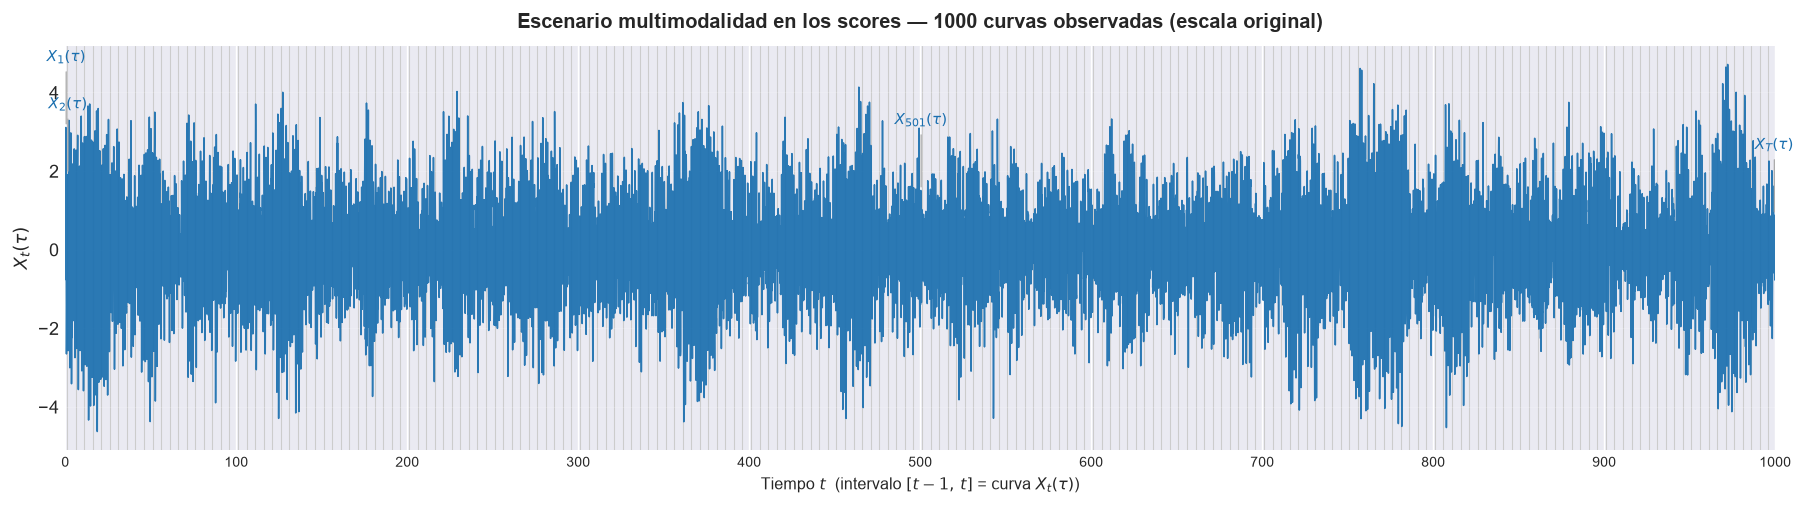

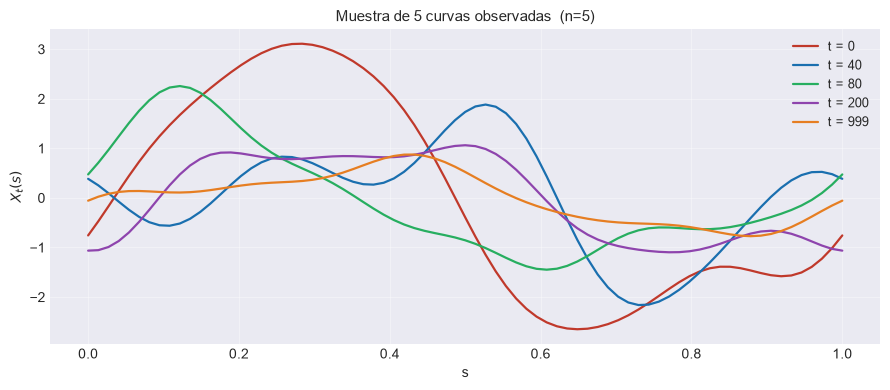

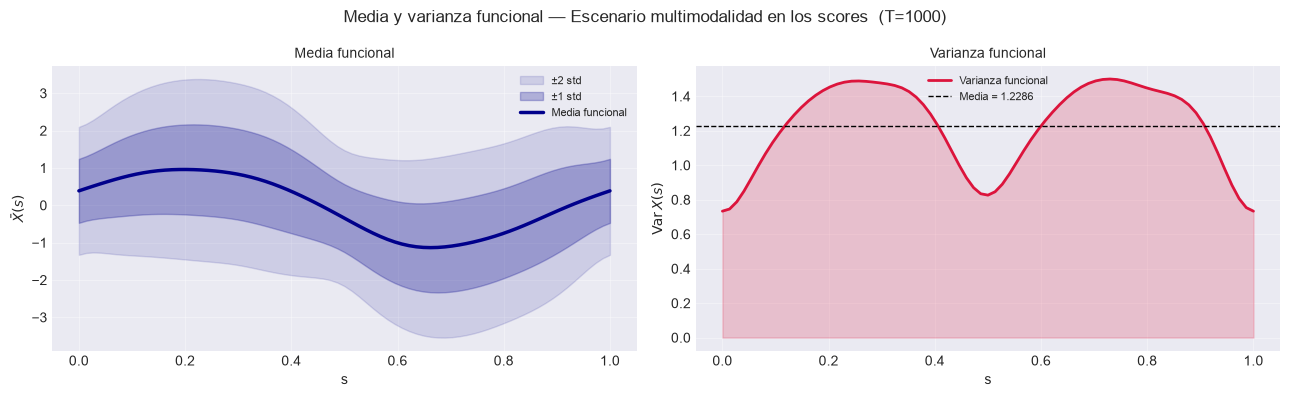

In [8]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"Escenario multimodalidad en los scores — {T} curvas observadas (escala original)")
replicar_figura("01_fts_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, 40, 80, 200, T - 1],
    title="Muestra de 5 curvas observadas")
replicar_figura("02_muestra_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title="Media y varianza funcional — Escenario multimodalidad en los scores")
replicar_figura("03_media_varianza_raw.png", PATHS_POR_M)
plt.show()

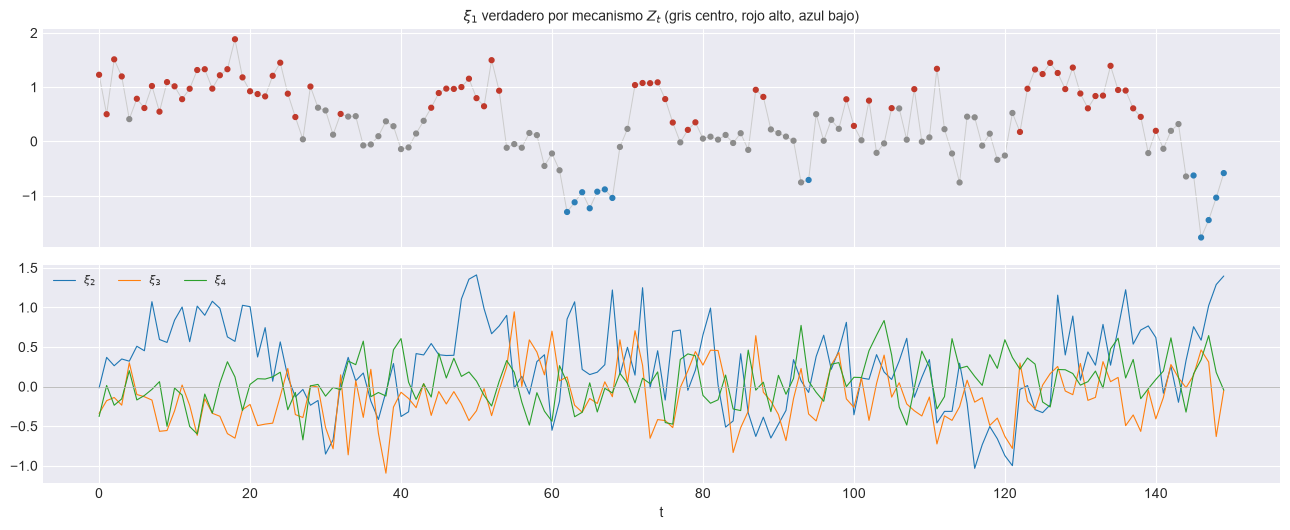

ocupación por mecanismo    : [0.451 0.267 0.282]
racha media por mecanismo  : [3.58 3.87 4.78]
R^2 L2 oráculo / lineal    : 0.4463 / 0.4232   (la multimodalidad está en la ley, no en la media)
R^2 oráculo  xi_1..5       : [0.639 0.369 0.159 0.159 0.108]
R^2 lineal   xi_1..5       : [0.631 0.315 0.106 0.125 0.143]
var. entre mecanismos/total: [0.179 0.049 0.173 0.16 ]
|cos| ejes (scores verd.)  : [0.998 0.997 0.998 0.992 0.989 0.99 ]


In [9]:
# Mecanismo sorteado y scores verdaderos xi (control de calidad; xi SON el insumo).
Z_hist  = salida.internos["mecanismo"][REPLICA_IDX]
XI_true = salida.internos["scores"][REPLICA_IDX]
_col    = np.array(["0.55", "#c0392b", "#2c7fb8"])
_n      = 150

fig, axes = plt.subplots(2, 1, figsize=(13, 5.4), sharex=True)
axes[0].plot(np.arange(_n), XI_true[:_n, 0], color="0.8", lw=0.7, zorder=0)
axes[0].scatter(np.arange(_n), XI_true[:_n, 0], c=_col[Z_hist[:_n]], s=12)
axes[0].set_title(r"$\xi_1$ verdadero por mecanismo $Z_t$ (gris centro, rojo alto, azul bajo)", fontsize=10)
for j in range(1, 4):
    axes[1].plot(np.arange(_n), XI_true[:_n, j], lw=0.8, label=rf"$\xi_{{{j+1}}}$")
axes[1].axhline(0, color="0.7", lw=0.6)
axes[1].set_xlabel("t"); axes[1].legend(fontsize=8, ncol=3)
fig.tight_layout()
replicar_figura("04b_mecanismo_scores.png", PATHS_POR_M, fig=fig)
plt.show()

_d = salida.diagnostico
print(f"ocupación por mecanismo    : {np.round(_d['ocupacion_mecanismos'], 3)}")
print(f"racha media por mecanismo  : {np.round(_d['racha_media_mecanismos'], 2)}")
print(f"R^2 L2 oráculo / lineal    : {_d['r2_oraculo']:.4f} / {_d['r2_lineal']:.4f}   (la multimodalidad está en la ley, no en la media)")
print(f"R^2 oráculo  xi_1..5       : {np.round(_d['r2_oraculo_por_componente'], 3)}")
print(f"R^2 lineal   xi_1..5       : {np.round(_d['r2_lineal_por_componente'], 3)}")
print(f"var. entre mecanismos/total: {np.round(_d['fraccion_varianza_entre_mecanismos'], 3)}")
print(f"|cos| ejes (scores verd.)  : {np.round(_d['cos_ejes_scores'][:6], 3)}")

### 2.4 Persistencia de curvas

Se guardan las dos matrices con nombres distintos (`X_curves.npy` y
`X_curves_true.npy`) para que no puedan confundirse aguas abajo.

In [10]:
_p = guardar_en_todos(guardar_curvas, PATHS_POR_M, X_raw, grilla, X_true=X_true)
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} -> {ruta.name}"
          f"   (replicado en {len(PATHS_POR_M)} directorios)")

[functional] curvas       -> X_curves.npy   (replicado en 4 directorios)
[functional] grilla       -> domain_grid.npy   (replicado en 4 directorios)
[functional] curvas_true  -> X_curves_true.npy   (replicado en 4 directorios)


### 2.5 Partición temporal

Todo objeto **estimado a partir de los datos** —los autovalores de la FPCA y el
estandarizador, que aquí queda en identidad— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

In [11]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 700]      → (700, 75)
prueba        : t ∈ [701, 1000]  → (300, 75)
proporción    : 70.0% / 30.0%


## 3. Representación funcional: base de Fourier del generador

Los scores son el insumo de los modelos que los usan, y los coeficientes de la curva se proyectan con **todos** los scores: la base es la de Fourier del generador, ortonormal en $L^2$, de modo que $\theta_t=\mu_\theta+\xi_t$ y la Gram es la identidad. **No hay GCV, ni B-spline, ni FPCA estimada.**

### 3.1 Base conocida y coeficientes

`FunctionalRepresentation.desde_base` no ajusta nada: proyecta con la base del generador. Como $\mu(\tau)=\sin(2\pi\tau)=\varphi_1/\sqrt2$ cae en la base, la representación es **exacta** y el objetivo `curva_suavizada` coincide con la curva verdadera.

In [12]:
Phi_base = salida.internos["Phi"]                 # (G, J) Fourier del generador, ortonormal en L2
MU_THETA = salida.internos["mu_theta"]            # (J,) proyeccion de mu en la base

fr          = FunctionalRepresentation.desde_base(Phi_base, grilla)
THETA       = fr.transform(X, grilla)             # (T, K = J): mu_theta + xi
THETA_train = THETA[idx_train]
X_SUAV      = fr.reconstruct(THETA)               # objetivo de evaluacion (docs 03_05_00)

assert np.allclose(THETA, MU_THETA + XI_true, atol=1e-10), "theta debe ser mu_theta + xi."
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")
print(f"|Gram - I|_max               = {np.abs(fr.gram_ - np.eye(fr.K_)).max():.2e}")
print(f"max|theta - (mu_theta + xi)| = {np.abs(THETA - (MU_THETA + XI_true)).max():.2e}")
print(f"MISE(suavizada, verdadera)   = {float((((X_SUAV - X_true)**2).mean(1)).mean()):.2e}")

guardar_en_todos(guardar_representacion, PATHS_POR_M, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "ninguno (base conocida)",
           "center": False, "n_basis": int(fr.K_), "order": None,
           "base": "fourier_generador"})
print(f"[functional] functional_representation.pkl + theta.csv + fr_config.json"
      f"   (replicado en {len(PATHS_POR_M)} directorios)")

THETA (1000, 10)  (train=700, test=300)
|Gram - I|_max               = 6.66e-16
max|theta - (mu_theta + xi)| = 1.78e-15
MISE(suavizada, verdadera)   = 2.78e-31
[functional] functional_representation.pkl + theta.csv + fr_config.json   (replicado en 4 directorios)


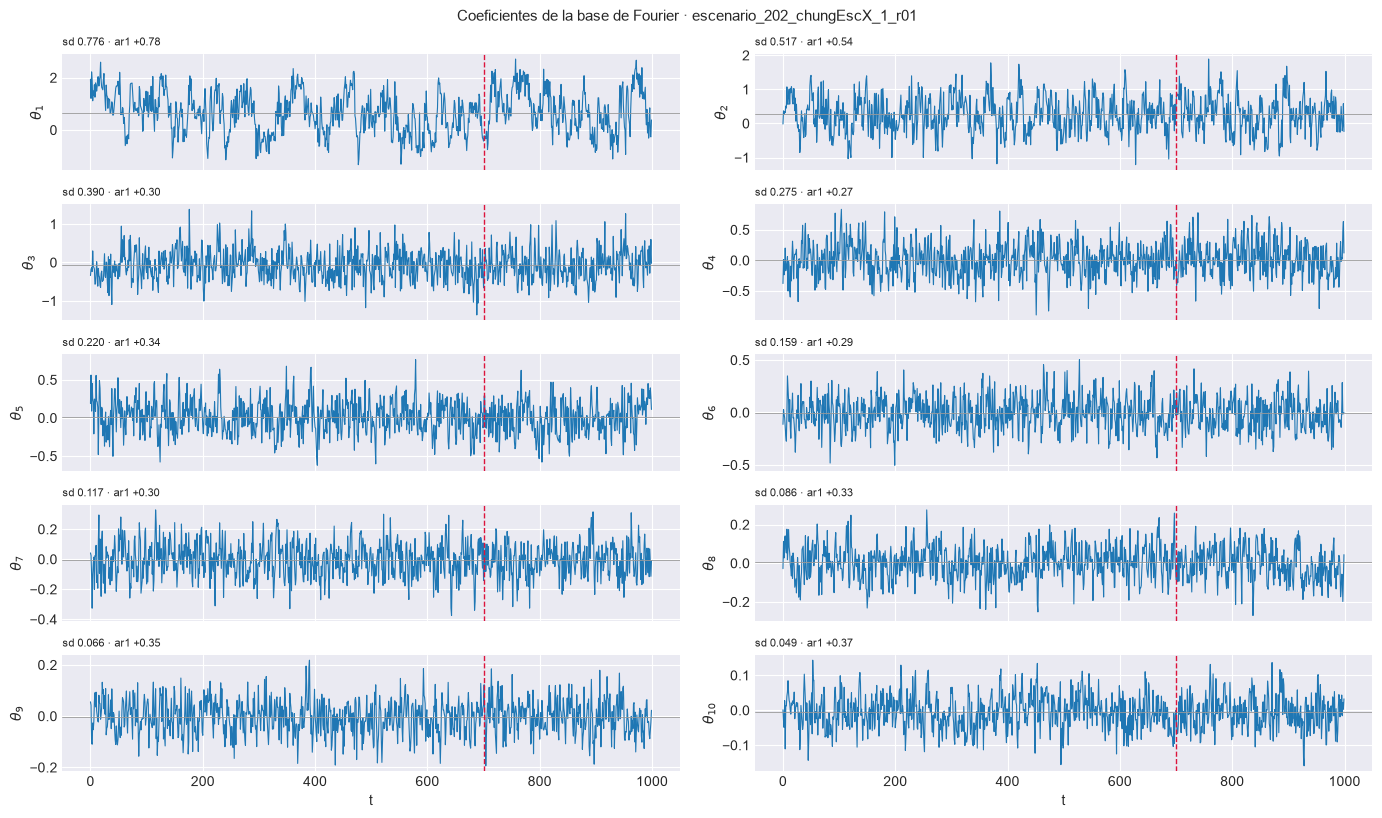

In [13]:
# Un panel por coeficiente theta_j = mu_theta + xi_j (la media funcional solo corre el nivel de theta_1).
fig = plot_series_componentes(
    THETA, T0=T0, simbolo=r"\theta",
    titulo=f"Coeficientes de la base de Fourier · {EXPERIMENT_BASE}")
replicar_figura("06_series_coeficientes.png", PATHS_POR_M, fig=fig)
plt.show()

### 3.2 FPCA de oráculo

La FPCA **no estima**: sus autofunciones son las $\varphi_j$ y sus scores los $\xi_{tj}$ del generador, en el orden de la base. Sólo los autovalores (varianza de cada score) se calculan con el bloque de entrenamiento. $K=J=10$ acota el barrido en $M$.

In [14]:
K = Phi_base.shape[1]
assert max(M_FPCA_LIST) <= K, (
    f"M_FPCA_LIST={list(M_FPCA_LIST)} excede K = J = {K} scores del generador.")

fpca = FPCA_L2.desde_scores_conocidos(
    Phi_base, grilla, MU_THETA, XI_true[idx_train].var(axis=0, ddof=1), n_ajuste=T0)

_ver = fpca.verificar(fr=fr)      # identidades estructurales (sin THETA_train: no hubo ajuste)
print("Verificación FPCA de oráculo:")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")
assert _ver["todo_ok"], "Las identidades estructurales de la FPCA de oráculo no se cumplen."

fpca.set_M(K)
assert np.allclose(fpca.transform(THETA), XI_true, atol=1e-10), "los scores deben ser xi."

VAR_TARGET = 0.95
M_SUGERIDO = fpca.seleccionar_M(VAR_TARGET)
print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")
for _M in M_FPCA_LIST:
    print(f"  M={_M}: var. acum = {fpca.var_cum[_M-1]:.4%}"
          + ("  ·  regla del 95 %" if _M == M_SUGERIDO else ""))

Verificación FPCA de oráculo:
  M                                  = 10
  K                                  = 10
  n_ajuste                           = 700
  cond_W                             = 1.000e+00
  err_ortonormalidad_L2              = 1.221e-15
  err_ortonormalidad_gram            = 1.665e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 8.882e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_linealidad_reconstruct_rel']
  todo_ok                            = True

K disponibles: 10   ·   sugerencia (var ≥ 95%): M = 5
  M=3: var. acum = 85.2356%
  M=4: var. acum = 91.5213%
  M=5: var. acum = 95.5660%  ·  regla del 95 %
  M=6: var. acum = 97.6776%


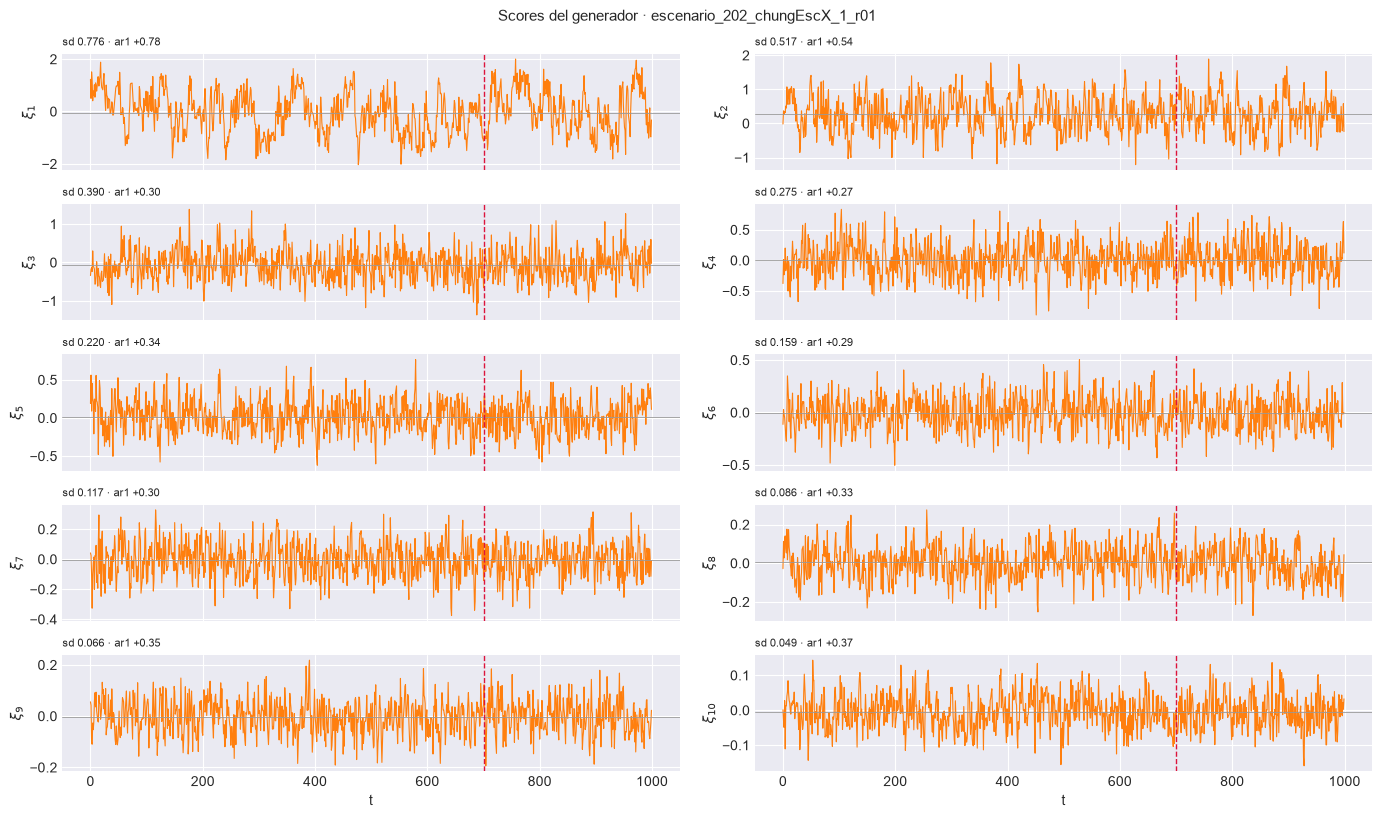

In [15]:
# Un panel por score xi_j, los J = K del generador (los que alimentan al modelo).
XI = fpca.transform(THETA)                       # (T, K), fpca con M = K
fig = plot_series_componentes(
    XI, T0=T0, simbolo=r"\xi", color="C1",
    titulo=f"Scores del generador · {EXPERIMENT_BASE}")
replicar_figura("07b_series_scores.png", PATHS_POR_M, fig=fig)
plt.show()

## 4. El bucle sobre `M_FPCA_LIST`

Se realiza:
- §4.1:`set_M(M)` y scores; contraste con la regla del 95 % 
- §4.2: estandarizador en **identidad** (los scores van crudos) y artefactos FPCA
- §4.3: diagnóstico de rezagos (Pearson y Spearman) sobre el bloque de entrenamiento
- §4.4: orden AR y construcción de los datasets
- §4.5: hiperparámetros y `mcmc_config` — el contrato con MATLAB
- §4.6: `eval_config`, líneas base y `verificar_contrato` 


In [16]:
# -- [CONFIG] Comunes a TODOS los puntos del barrido -------------------------
# Rezago propio: xi_(k,t) se predice con xi_(k,t-l), l = 1..N_LAGS. N_LAGS es
# el L del anexo: no es perilla.
N_LAGS = 2
assert N_LAGS >= SIM_CFG.n_rezagos, (
    f"N_LAGS={N_LAGS} < n_rezagos={SIM_CFG.n_rezagos} del simulador: el pipeline debe ver al menos los rezagos del generador.")

MCMC_CONFIG = {"nsim": 2500, "burn": 500, "N": VAR_CFG["N"], "M": 50}   # ojo: ese M es G*
N_CHAINS    = 3

HP_GLOBAL = {"atau": 0.5, "btau": 0.5, "ag": 0.5, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Chung §4.2 llevado a la escala cruda. Si x = sd*z, el prior del paper sobre z
# equivale a taupsij = taupsij_z*sd_x^2 y btau = 0.5*sd_y^2 (se aplican en
# procesar_punto). Inclusion: Chung en el lag 1, bpij = 5 del lag 2 en adelante.
HP_CHUNG_ESC = {"taupsij_z": float(VAR_CFG.get("taupsij_z", 100.0)), "btau_z": 0.5,
                "ab_por_lag": {l: (0.5, 0.5) if l == 1 else (0.5, 5.0)
                               for l in range(1, N_LAGS + 1)},
                "ab_cruzado": (0.5, 5.0)}
HP_BY_TYPE = {f"own_lag{l}": {"apij": HP_CHUNG_ESC["ab_por_lag"][l][0],
                              "bpij": HP_CHUNG_ESC["ab_por_lag"][l][1]}
              for l in range(1, N_LAGS + 1)}
# Cruzados (variante chungEscX): mismo prior de inclusion para todo rezago ajeno.
HP_BY_TYPE.update({f"cross_lag{l}": {"apij": HP_CHUNG_ESC["ab_cruzado"][0],
                                     "bpij": HP_CHUNG_ESC["ab_cruzado"][1]}
                   for l in range(1, N_LAGS + 1)})
print(f"VARIANTE {VARIANTE!r}: HP_GLOBAL={HP_GLOBAL}")
for _t, _v in HP_BY_TYPE.items():
    print(f"  {_t}: apij={_v['apij']}, bpij={_v['bpij']}  E[pi]={_v['apij'] / (_v['apij'] + _v['bpij']):.3f}")
print(f"N={MCMC_CONFIG['N']}  ·  mupsij=0, taupsij={HP_CHUNG_ESC['taupsij_z']:g}*sd_x^2, "
      "btau=0.5*sd_y^2 (Chung en escala cruda)")

# Lo común a todos los puntos del barrido: `preparar_punto` no recalcula nada de esto, y esa
# es la garantía de que los puntos comparten realización y base.
CTX = dict(
    PATHS_POR_M=PATHS_POR_M, BASENAME=BASENAME, ESCENARIO_ID=ESCENARIO_ID, REPLICA_ID=REPLICA_ID,
    SEED=SEED, fpca=fpca, THETA=THETA, idx_train=idx_train, idx_test=idx_test, T=T, T0=T0,
    PROP_TRAIN=PROP_TRAIN, N_LAGS=N_LAGS, CRUZADOS=CRUZADOS, M_ENTRENO=M_ENTRENO,
    M_SUGERIDO=M_SUGERIDO, HP_GLOBAL=HP_GLOBAL, HP_BY_TYPE=HP_BY_TYPE, HP_CHUNG_ESC=HP_CHUNG_ESC,
    VARIANTE=VARIANTE, VAR_CFG=VAR_CFG, MCMC_CONFIG=MCMC_CONFIG, N_CHAINS=N_CHAINS,
    X_SUAV=X_SUAV, grilla=grilla,
)

RESUMEN = [preparar_punto(M, CTX) for M in M_FPCA_LIST]


VARIANTE 'chungEscX': HP_GLOBAL={'atau': 0.5, 'btau': 0.5, 'ag': 0.5, 'bg': 0.5, 'mumu': 0.0, 'taumu': 1.0, 'pwj': 0.5}
  own_lag1: apij=0.5, bpij=0.5  E[pi]=0.500
  own_lag2: apij=0.5, bpij=5.0  E[pi]=0.091
  cross_lag1: apij=0.5, bpij=5.0  E[pi]=0.091
  cross_lag2: apij=0.5, bpij=5.0  E[pi]=0.091
N=30  ·  mupsij=0, taupsij=10*sd_x^2, btau=0.5*sd_y^2 (Chung en escala cruda)

M = 3   ·   escenario_202_chungEscX_1_r01_m03
M(95 %) segun la regla : 5   (K disponible = 10)
M de este punto        : 3   <- DIFIERE de la regla: es un punto de sensibilidad
M = 3   var. explicada = 85.2356%
[train] max|media xi| = 2.67e-01   (~ 0)
[test]  max|media xi| = 0.282
[test]  var xi / lambda = [1.139 1.039 1.031]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

[functional] artefactos FPCA · cond_W = 1.000e+00
componentes : 3
N_LAGS      : 2   ·   p = 6 covariable(s) por componente (todos_los_rezagos)
n_train_eff : 698   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3

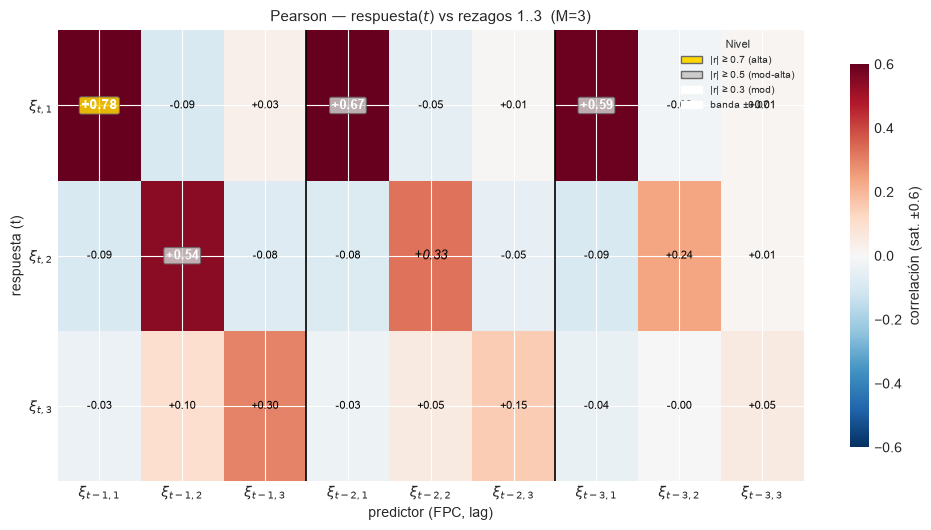

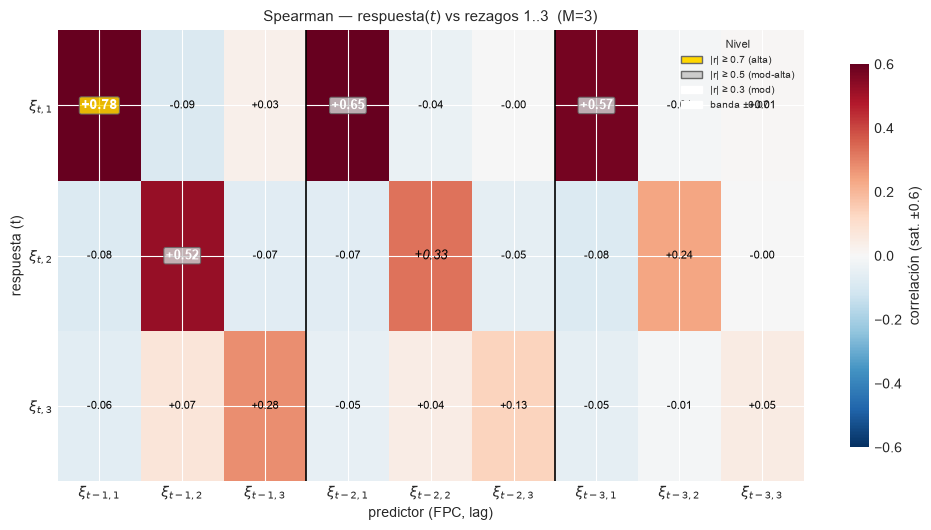

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,300.0000,0.8334,0.5974,0.4016,0.6108,-0.1099,1.3875,1.1779
persistencia_lag1,300.0000,0.5534,0.4989,0.4722,0.5082,0.0775,0.9530,0.9762


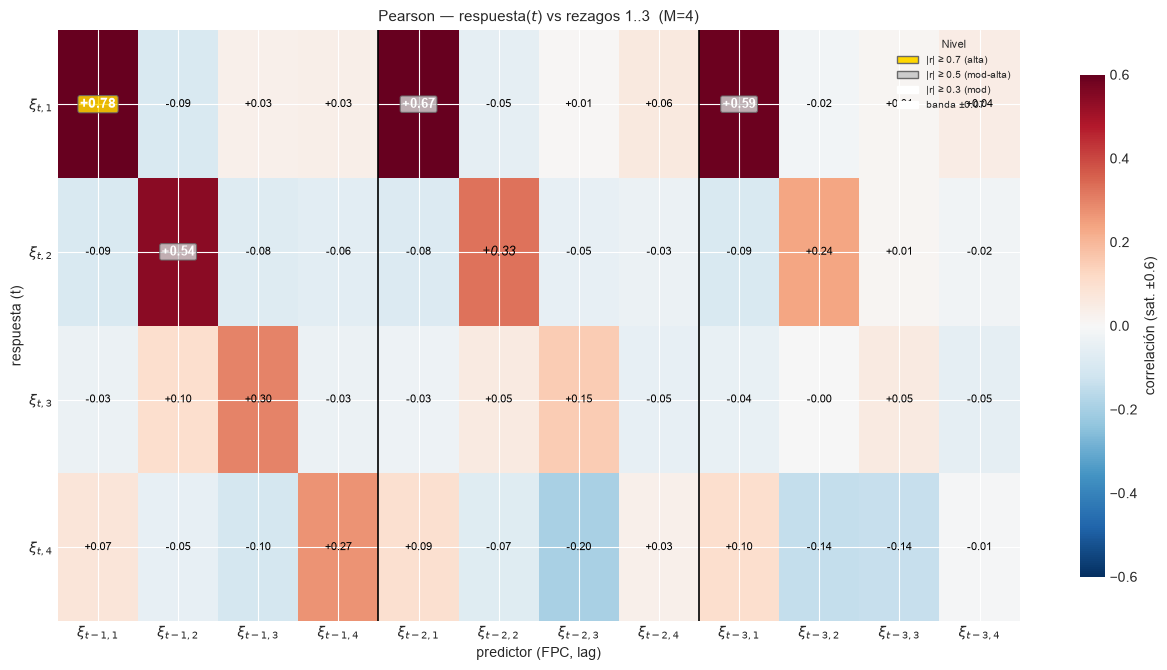

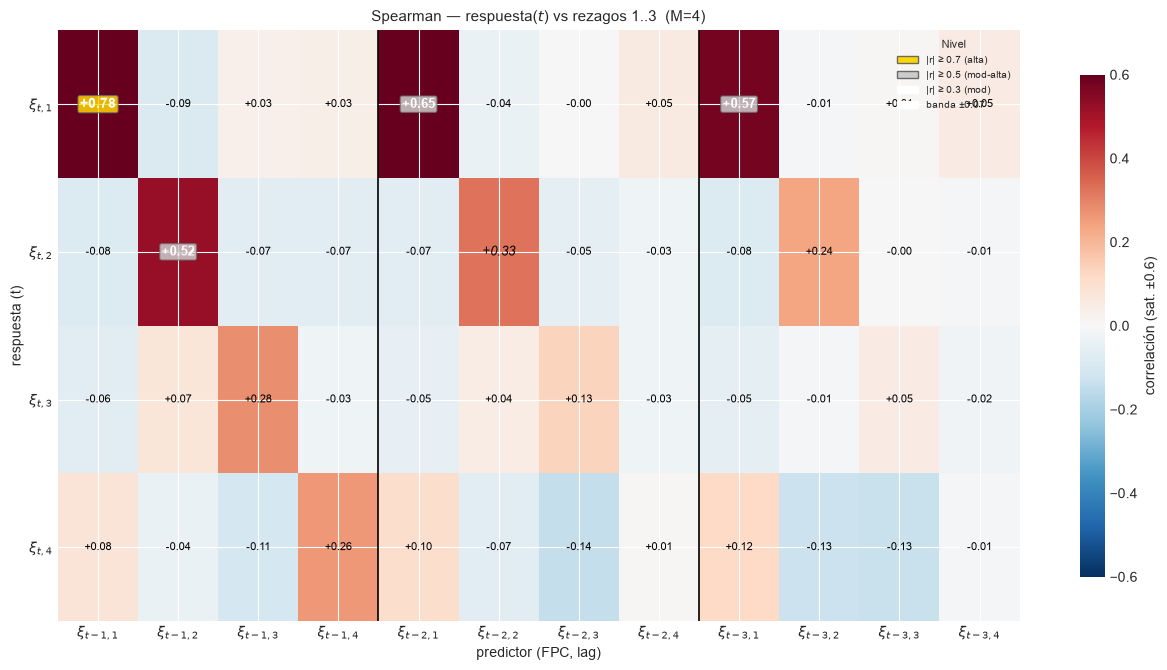

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,
media_incondicional,300.0000,0.8334,0.5974,0.4016,0.2756,0.5270,-0.0846,1.3875,1.1779
persistencia_lag1,300.0000,0.5534,0.4989,0.4722,0.3392,0.4659,-0.0737,0.9920,0.9960


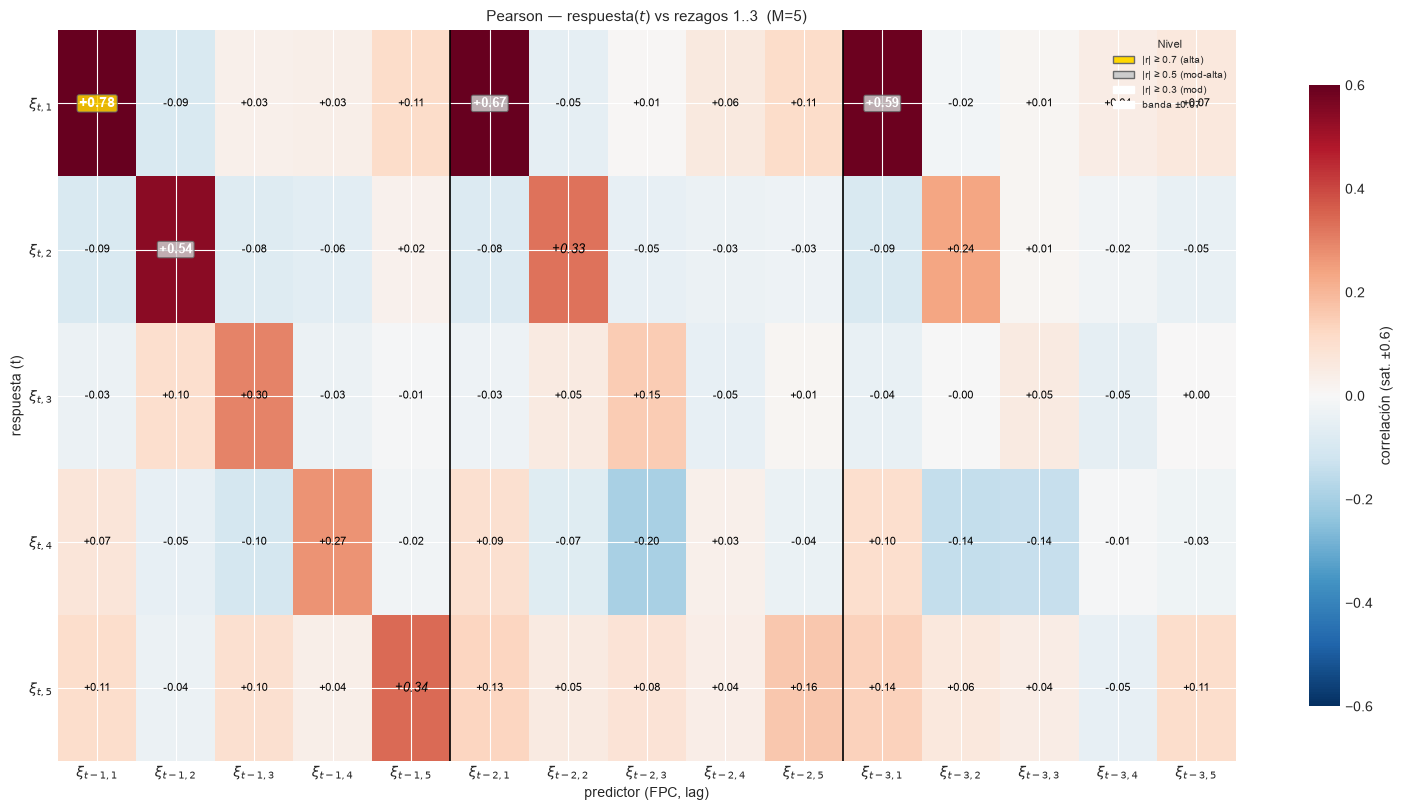

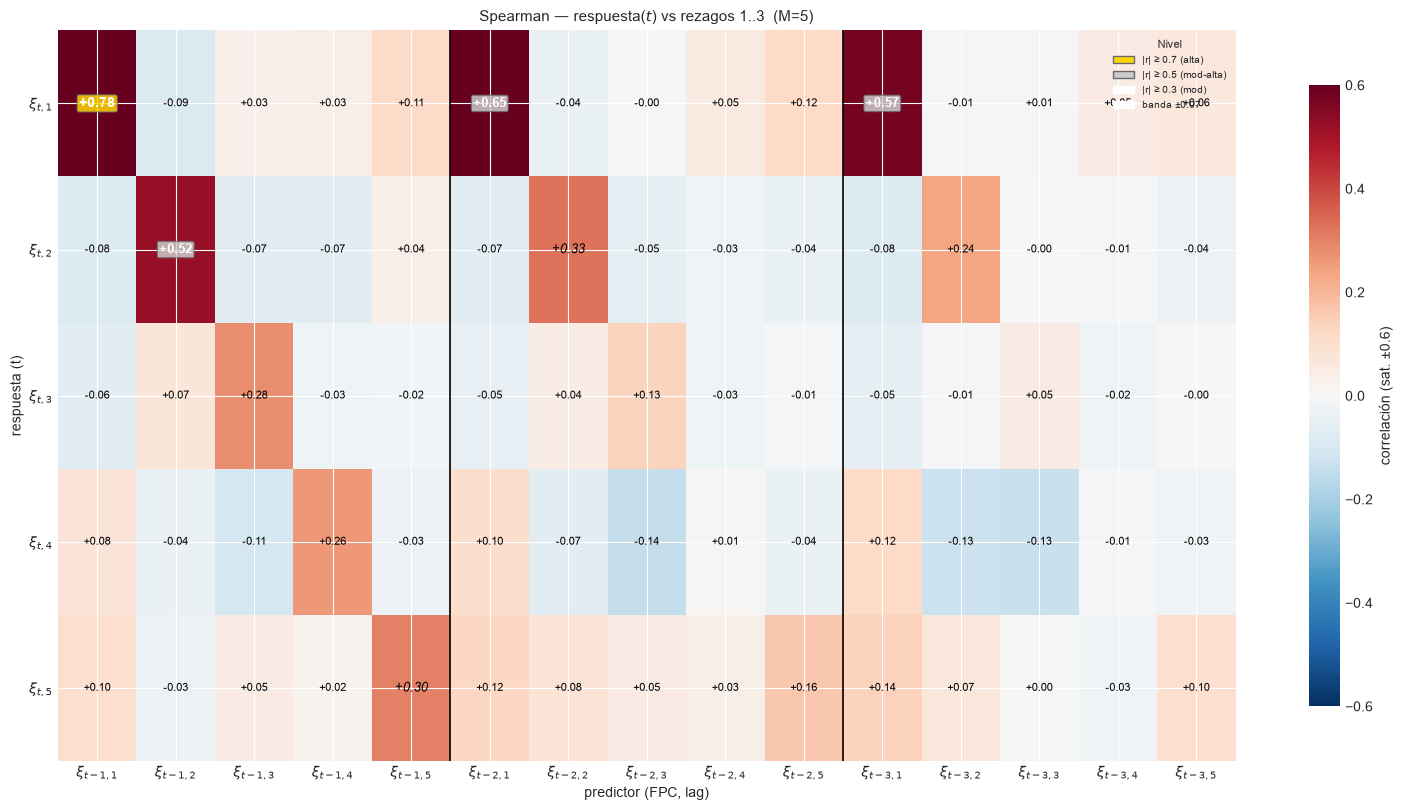

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,
media_incondicional,300.0000,0.8334,0.5974,0.4016,0.2756,0.2212,0.4658,-0.0677,1.3875,1.1779
persistencia_lag1,300.0000,0.5534,0.4989,0.4722,0.3392,0.2587,0.4245,-0.1325,1.0100,1.0050


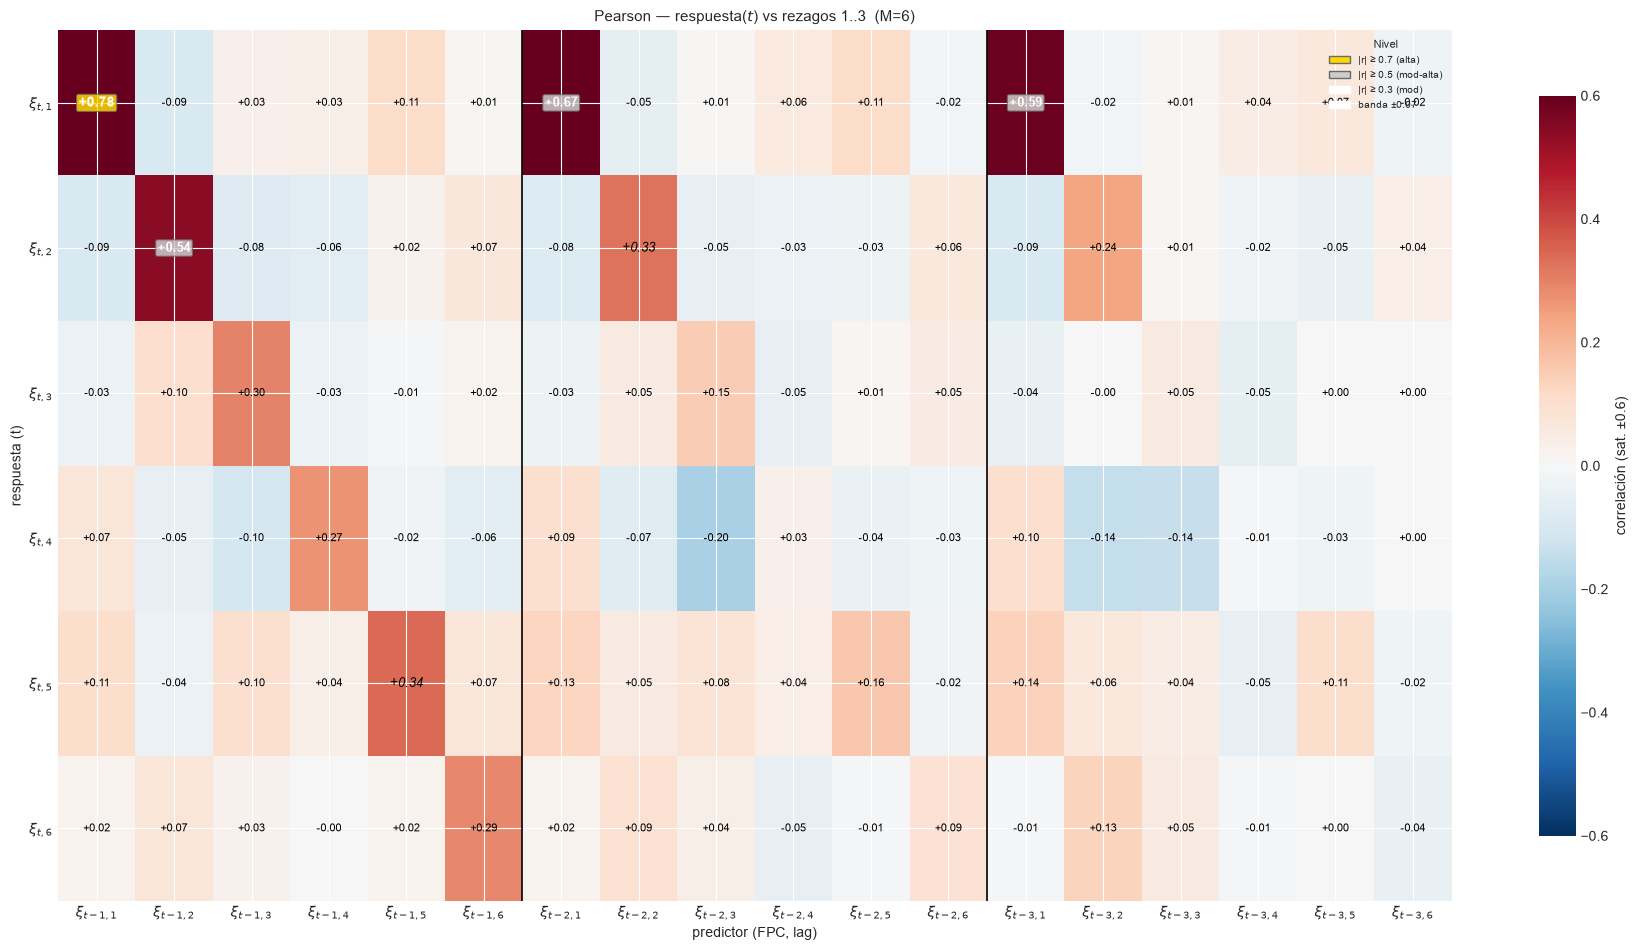

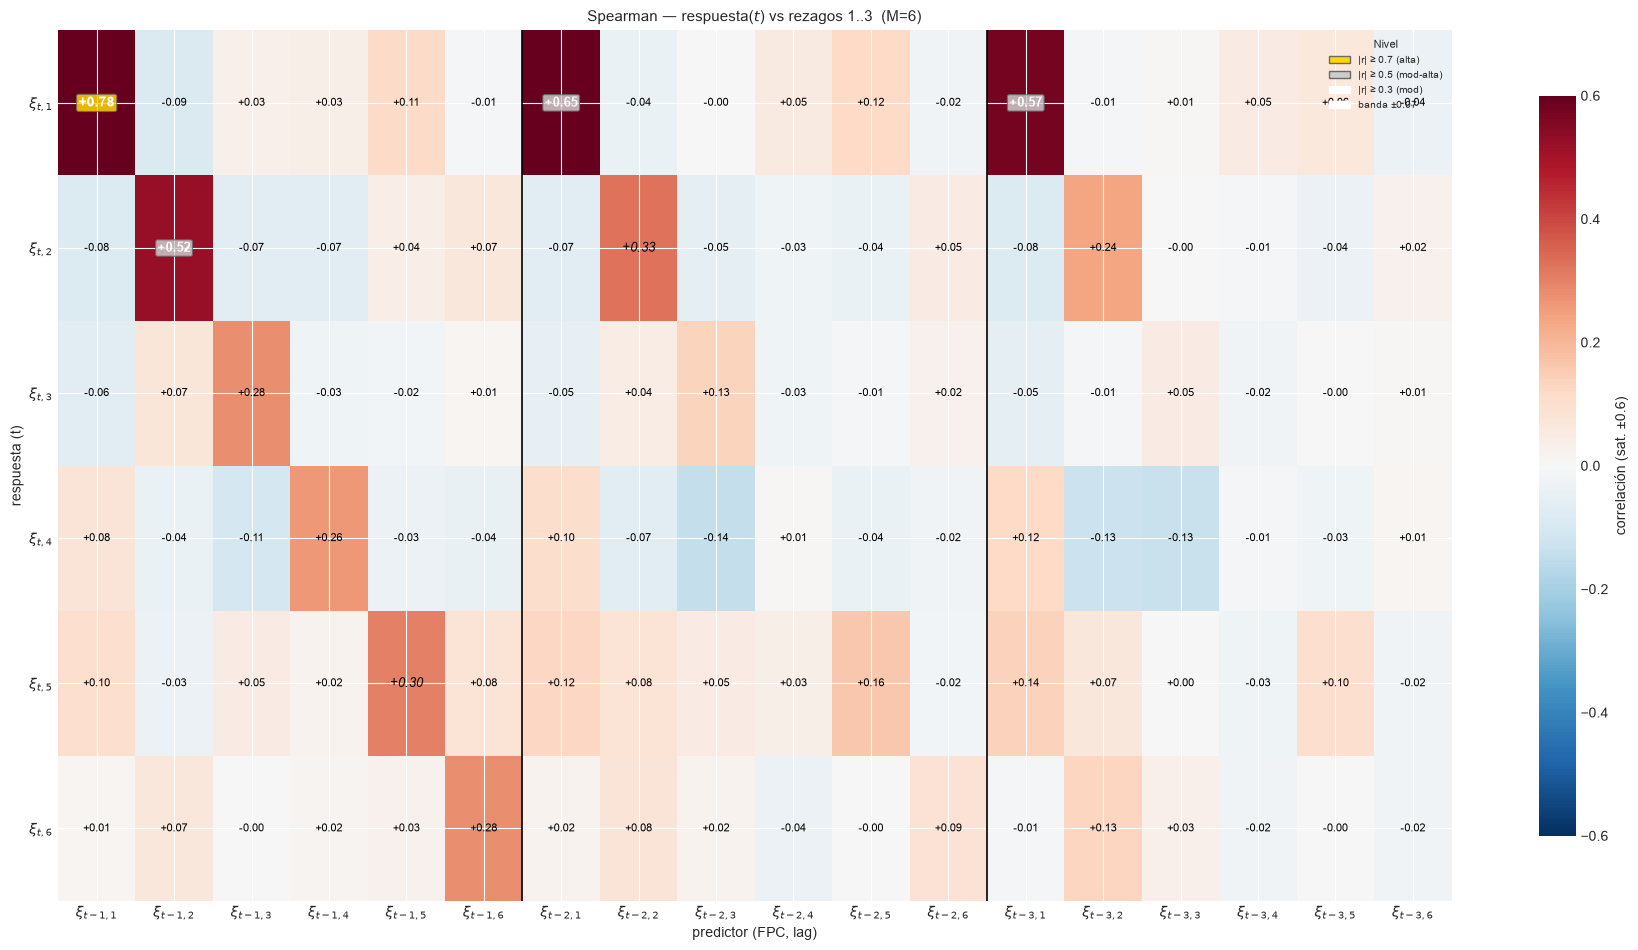

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,
media_incondicional,300.0000,0.8334,0.5974,0.4016,0.2756,0.2212,0.1545,0.4139,-0.0583,1.3875,1.1779
persistencia_lag1,300.0000,0.5534,0.4989,0.4722,0.3392,0.2587,0.1917,0.3857,-0.2031,1.0229,1.0114


In [17]:
# Diagnóstico de rezagos (sólo train) y líneas base a h=1, por punto del barrido.
for r in RESUMEN:
    plot_diagnostico_rezagos(r["diagnostico_rezagos"], r["M"], PATHS_POR_M[r["M"]]["out_report"])
    plt.show()
    display(r["baselines"].style.format("{:.4f}", na_rep="-")
            .set_caption(f"Líneas base (M={r['M']}) — prueba, h=1, contra la curva SUAVIZADA"))

## 5. Resumen del barrido

In [18]:
resumen_df = pd.DataFrame(RESUMEN).set_index("M")
display(resumen_df[["experiment_id", "var_acum", "K", "coincide_regla_95",
                    "n_components", "p_covariables", "contrato_ok"]]
        .style.format({"var_acum": "{:.4%}"})
        .set_caption(f"Barrido en M · {EXPERIMENT_BASE} · "
                     f"K disponible = {resumen_df['K'].iloc[0]}"))

_fallidos = [r for r in RESUMEN if not r["contrato_ok"]]
for r in _fallidos:
    print(f"\n[FALLA] M={r['M']} ({r['experiment_id']}):")
    for p in r["problemas"]:
        print(f"  - {p}")
assert not _fallidos, (
    f"El contrato falla en M = {[r['M'] for r in _fallidos]}. No lanzar MATLAB: "
    f"psbp_fd_iteracion.m leería artefactos inconsistentes.")

print(f"\n{'='*70}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      + (f"con M_FPCA_LIST = {list(M_FPCA_LIST)}   (cruzados: se entrena CADA M)\n"
         if CRUZADOS else
         f"con M_FPCA_LIST = [{M_ENTRENO}]   (solo se entrena M={M_ENTRENO}: "
         f"los M menores reutilizan sus trazas)\n")
      + f"Antes, correr este notebook con cada VARIANTE de {list(VARIANTES)}.\n{'='*70}")

,experiment_id,var_acum,K,coincide_regla_95,n_components,p_covariables,contrato_ok
M,,,,,,,
3,escenario_202_chungEscX_1_r01_m03,85.2356%,10,False,3,6,True
4,escenario_202_chungEscX_1_r01_m04,91.5213%,10,False,4,8,True
5,escenario_202_chungEscX_1_r01_m05,95.5660%,10,True,5,10,True
6,escenario_202_chungEscX_1_r01_m06,97.6776%,10,False,6,12,True



Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
con M_FPCA_LIST = [3, 4, 5, 6]   (cruzados: se entrena CADA M)
Antes, correr este notebook con cada VARIANTE de ['chungEscX'].
